# Assignment 6 — Generation Experiment

**DATAX504** · Due end of Week 11

Choose **text** or **image** generation. This notebook is intentionally sparse: pick a small, runnable experiment you can defend in the reflection.

## Tasks
1. Train or adapt a small generator (char-RNN / small LM, GAN, VAE, simple diffusion demo, …)
2. Show **5 samples** in this notebook
3. Name the main **failure mode** you observed
4. After reading the [HF diffusion language models post](https://huggingface.co/blog/ProCreations/diffusion-language-model), write ~150 words on AR vs diffusion trade-offs

## Moodle fields
`a6_repo`, `a6_modality`, `a6_failure`, `a6_diffusion_reflection`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude (Anthropic), Claude Sonnet 5.5 via claude.ai |
| Used for | Explaining the assignment, helping structure the notebook, drafting/debugging Python/Keras code, and helping draft the reflection. |
| Verified how | Ran the notebook end-to-end myself in VS Code; read through every line of the code and checked I can explain it; inspected the 5 samples and the temperature comparison myself to identify the failure mode; read the Hugging Face post myself and edited the reflection to match what I understood |
| Not used for | The AI did not produce the model's training results or generated samples; those outputs were produced by running the notebook.|


In [1]:
MODALITY = "text"  # "text" or "image" — Moodle a6_modality

import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

# Make results repeatable
keras.utils.set_random_seed(42)

print("Selected modality:", MODALITY)
print("Keras version:", keras.__version__)


Selected modality: text
Keras version: 3.15.1


## Experiment

**Text track: character-level generator on Shakespeare.**

- **Data:** Tiny Shakespeare (~1.1M characters, from the TensorFlow tutorial dataset). To keep training laptop-friendly I use the first 400,000 characters.
- **Model:** Embedding → GRU → Dense(softmax). It reads 60 characters and predicts the *next* character (an autoregressive model).
- **Training:** Adam, cross-entropy loss, 8 epochs, CPU is fine.
- **Sampling:** start from a seed string, predict a probability distribution over the next character, sample from it (with a *temperature*), append, repeat.


In [2]:
assert MODALITY == "text", "This notebook implements the text track. Set MODALITY = 'text'."

# ---------- 1. Load data ----------
URL = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
try:
    path = keras.utils.get_file("shakespeare.txt", URL)
except Exception as e:
    # Fallback: download the URL manually in your browser and save it next to this notebook
    print("Download failed:", e)
    path = "shakespeare.txt"

text = open(path, "r", encoding="utf-8").read()
text = text[:400_000]                      # smaller subset so it trains quickly
print("Characters used:", len(text))
print(text[:300])


Characters used: 400000
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [3]:
# ---------- 2. Turn characters into numbers ----------
chars = sorted(set(text))
vocab_size = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
print("Vocabulary size:", vocab_size)

encoded = np.array([char2idx[c] for c in text], dtype="int32")

# Each training example: 60 characters in -> the 61st character is the target
SEQ_LEN = 60
STRIDE = 3          # step between windows (bigger = fewer examples = faster)

X, y = [], []
for i in range(0, len(encoded) - SEQ_LEN, STRIDE):
    X.append(encoded[i:i + SEQ_LEN])
    y.append(encoded[i + SEQ_LEN])
X, y = np.array(X), np.array(y)
print("X shape:", X.shape, " y shape:", y.shape)


Vocabulary size: 63
X shape: (133314, 60)  y shape: (133314,)


In [4]:
# ---------- 3. Model ----------
model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(vocab_size, 32),
    layers.GRU(256),
    layers.Dense(vocab_size, activation="softmax"),
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam")
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 32)         │         2,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 256)            │       222,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 63)             │        16,191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,927 (941.12 KB)

 Trainable params: 240,927 (941.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
990/990 - 98s - 99ms/step - loss: 2.4500 - val_loss: 2.1701
Epoch 2/8
990/990 - 97s - 98ms/step - loss: 1.9744 - val_loss: 1.9458
Epoch 3/8
990/990 - 97s - 98ms/step - loss: 1.7693 - val_loss: 1.8287
Epoch 4/8
990/990 - 97s - 98ms/step - loss: 1.6418 - val_loss: 1.7589
Epoch 5/8
990/990 - 97s - 98ms/step - loss: 1.5485 - val_loss: 1.7193
Epoch 6/8
990/990 - 97s - 98ms/step - loss: 1.4725 - val_loss: 1.7002
Epoch 7/8
990/990 - 97s - 98ms/step - loss: 1.4068 - val_loss: 1.6965
Epoch 8/8
990/990 - 95s - 96ms/step - loss: 1.3476 - val_loss: 1.7047


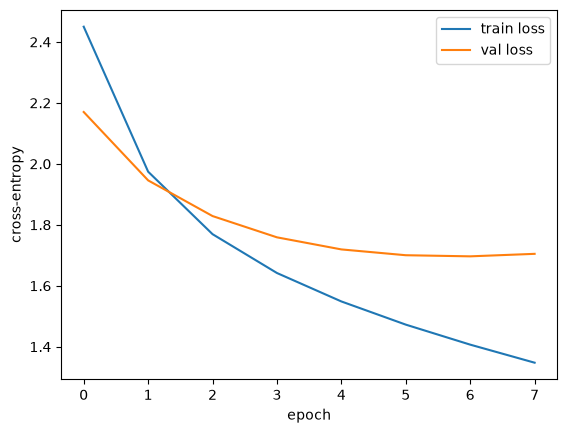

In [5]:
# ---------- 4. Train ----------
history = model.fit(X, y, batch_size=128, epochs=8, validation_split=0.05, verbose=2)

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy"); plt.legend(); plt.show()


In [6]:
# ---------- 5. Sampling ----------
def sample_next(probs, temperature=1.0):
    # temperature < 1 -> safer/more repetitive, > 1 -> more random
    probs = np.asarray(probs, dtype="float64")
    probs = np.log(probs + 1e-9) / temperature
    probs = np.exp(probs)
    probs /= probs.sum()
    return np.random.choice(len(probs), p=probs)

def generate(seed, length=300, temperature=0.8):
    seed = seed[-SEQ_LEN:].rjust(SEQ_LEN)          # pad/trim seed to 60 chars
    window = [char2idx.get(c, 0) for c in seed]
    out = seed.strip()
    for _ in range(length):
        probs = model.predict(np.array([window]), verbose=0)[0]
        nxt = sample_next(probs, temperature)
        out += idx2char[nxt]
        window = window[1:] + [nxt]
    return out

seeds = ["ROMEO:\n", "First Citizen:\n", "KING HENRY:\n", "JULIET:\n", "Second Citizen:\n"]
for i, s in enumerate(seeds, 1):
    print(f"===== SAMPLE {i} (seed={s.strip()!r}, temperature=0.8) =====")
    print(generate(s, length=300, temperature=0.8))
    print()


===== SAMPLE 1 (seed='ROMEO:', temperature=0.8) =====
ROMEO:His back, I'll be not in rele of your lord
is in atterrone is the bofy.

QUEEN ELIZABETH:
And the Hand om my againstame to a prick-hals him; and and every.

QUEEN ELIZABETH:
Have, have mother, let us no shall as not is the earth;
Dour shallest at would have faly is remestly queen;
Net he made and of

===== SAMPLE 2 (seed='First Citizen:', temperature=0.8) =====
First Citizen:And to dear Iffice for arm, and Edpasting he?

BRUTUS:
Marrot, my some I last
That with thy diest record up the winderior,
And what sain unchood, when in all all,
In ever yours lord, my Lord of Yorkyer his rire.
What to service andiw, what when I mester you
dis banishment on him it is be a seaven,
A

===== SAMPLE 3 (seed='KING HENRY:', temperature=0.8) =====
KING HENRY:But I dear with a soldiers that kill'd hath before
The cheep, if I dear he was with with him feed
I pain your queenly.

SICINIUS:
Hear you in reatly, as gentleman,
And him blood, the emplect

In [7]:
# ---------- 6. Look for the failure mode: same seed, different temperatures ----------
for t in [0.2, 0.5, 1.2]:
    print(f"===== temperature={t} =====")
    print(generate("ROMEO:\n", length=300, temperature=t))
    print()


===== temperature=0.2 =====
ROMEO:And lords and have been the seet the seet
The have did report the seem the consul of the world,
That is no mour of the warse prove in power
That we have being so her his prove and requesters
That be stand be the seet the commons the hards
That with the best a fair but of my lord,
The seem the best a

===== temperature=0.5 =====
ROMEO:What the consent time to have your hands
I have should be the cown against the gods.

BRUTUS:
I that I cannot better the Lord of Lord Heneford,
The dead to seem to my pombour singe
That when I die, come his posies the boys;
And lords he have deed the have deed in and amon
With your voices of my lord

===== temperature=1.2 =====
ROMEO:What, trow agor highers withfuc plet, To,
Repred, fare, both novest old as this enbly?
If IUn:
Here yet to thy say, thunk, a deed say, purbour you
mid tooed me't villerance, which dee envie the COmains,
Friends upoun liftle tru! Alaur his hig.
You maty tidoes Capisable, villair: stund gold!

C

## Failure mode (Moodle `a6_failure`)

One short phrase is enough for Moodle (e.g. repetition, mode collapse, blur). Expand briefly below if useful.


*Failure mode observed:* **repetition loops at low temperature, and nonsense words at high temperature**

My model learned the *surface form* of Shakespeare (speaker names in capitals, colons, line breaks, archaic words) but not meaning, and how it fails depends on the sampling temperature:

- **Temperature 0.2 → repetition loops.** It almost always picks the most likely next character, so it gets stuck, e.g. "the seet the seet" and "That be stand be the seet the commons the hards".
- **Temperature 1.2 → nonsense words.** It often samples unlikely characters, giving invented words like "withfuc plet" and "purbour".
- **Temperature 0.8 (the 5 samples) → in between.** Output looks like a play but contains stuttered words ("with with", "all all", "and and") and made-up words ("atterrone", "bofy"). Sentences do not make sense and the speakers change randomly.

The cause is that the GRU only sees the last 60 characters and predicts one character at a time, so it cannot plan a sentence or keep an idea going. Validation loss also stopped improving after epoch 7 (1.6965 → 1.7047) while training loss kept falling (1.35), so the model was starting to overfit this small 400,000-character subset.


## AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

~150 words after the HF reading: compare autoregressive vs diffusion-style generation for *your* modality (quality, control, compute, failure modes).


*Reflection (~150 words):*

My model is autoregressive: it writes one character at a time, left to right, and every choice is final. This was simple to train and cheap on a laptop, but my samples show the weakness. At temperature 0.2 it fell into loops ("the seet the seet") and could not go back and repair them, so early mistakes compound. Diffusion language models, as described in the Hugging Face post, instead start from masked or noisy text and refine the whole sequence over several denoising steps. This gives bidirectional context, so they can revise and infill, can generate many tokens in parallel, and let you trade speed for quality through the number of steps. The post also suggests they can be more controllable and avoid issues like the reversal curse. The costs are more complex training, higher compute per output, and a less mature ecosystem. For my Shakespeare task, diffusion might reduce repetition but would be harder to build.
